In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.shape

(8807, 12)

In [3]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [ ]:
** The dataset has 8807 rows and 12 columns.
    And the datatypes are all objects.

In [4]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [ ]:
** The are no duplicate values in the dataset but  several columns have 
missing values: director (2,634 missing), cast (825), country (831), 
date_added (10), rating (4), and duration (3).

In [7]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [ ]:
** we can see their are 6131 movies and 2676 tv shows

In [8]:
df["country"].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [ ]:
*** united states produce more content follwed by india and united kindom.

release_year
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


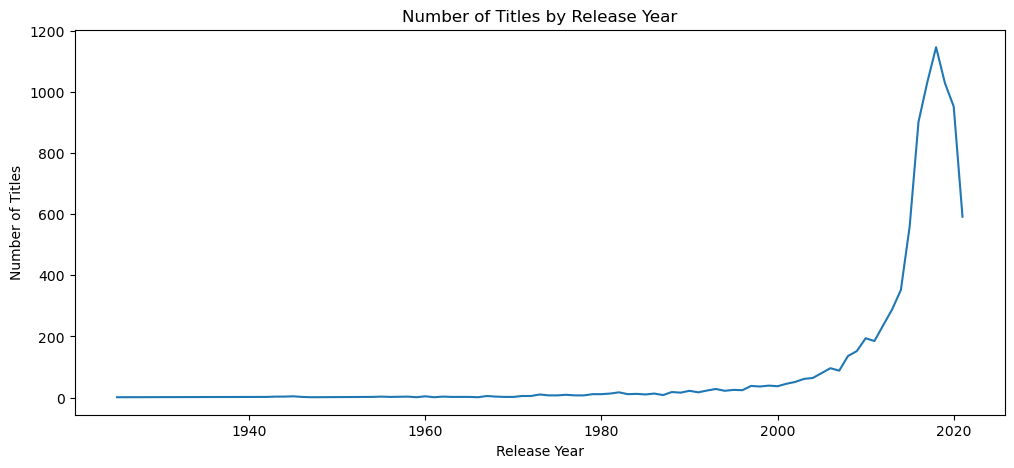

In [15]:
release_by_year = df["release_year"].value_counts().sort_index()
print(release_by_year.tail(10))

plt.figure(figsize=(12,5))
release_by_year.plot(kind="line")
plt.title("Number of Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

In [ ]:
***AS the years passes the number titles grows slowly unitl 2000.
    after the year 2000 the numbe of titels grown rapidly and reached to 1147 then
    decreased to 953.

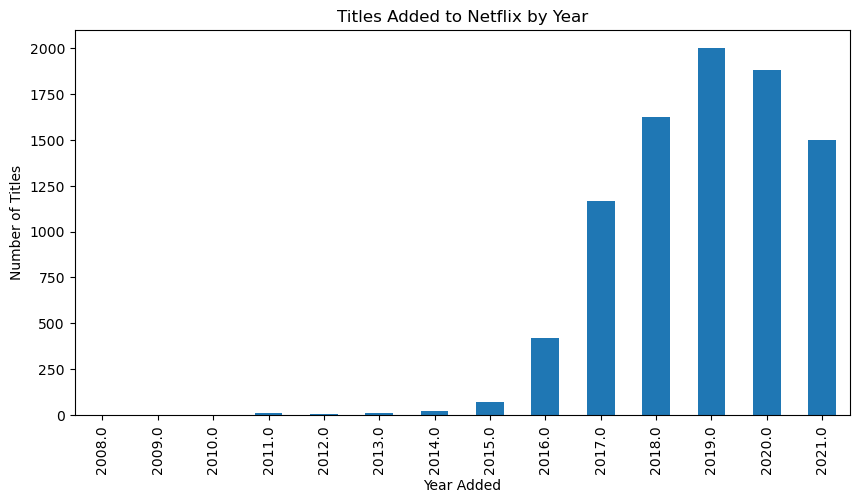

In [19]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year

df["year_added"].value_counts().sort_index().plot(kind="bar", figsize=(10,5))
plt.title("Titles Added to Netflix by Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()

In [ ]:
*** 2019 added the most number titles to netflix followed by 2020 and 2018. 

In [20]:
directors = df[df["director"] != "Unknown"]["director"]
directors_split = directors.str.split(", ").explode()

print(directors_split.value_counts().head(10))

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Jay Chapman            12
Youssef Chahine        12
Martin Scorsese        12
Name: count, dtype: int64


In [22]:
cast = df[df["cast"] != "Unknown"]["cast"]
cast_split = cast.str.split(", ").explode()

print(cast_split.value_counts().head(10))

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Paresh Rawal        28
Name: count, dtype: int64


In [30]:
genres = df["listed_in"].str.split(", ").explode()

print(genres.value_counts().head(10))

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


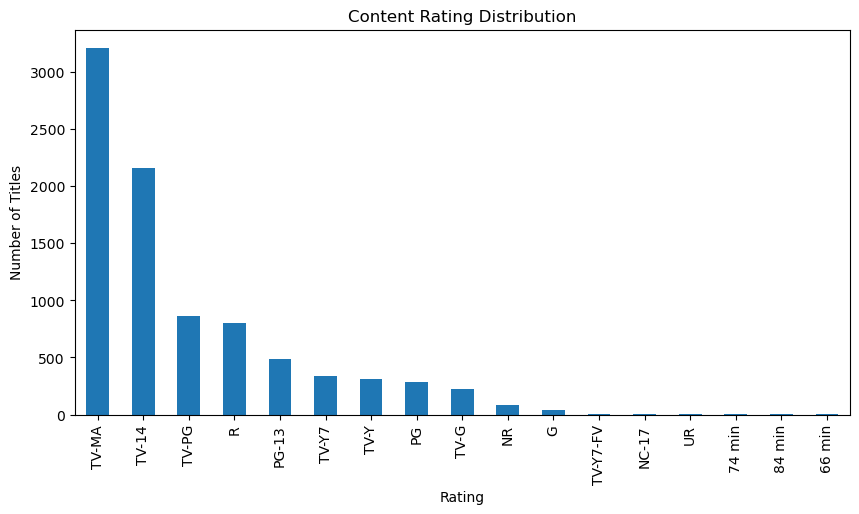

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [34]:
plt.figure(figsize=(10,5))
df["rating"].value_counts().plot(kind="bar")
plt.title("Content Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.show()

print(df["rating"].value_counts())

In [ ]:
** we can see tv-maa has more number of titles and have more common ratings.
  that means netflix targets adult audience and very small position is dedicated to
kids (eg:tv-y,tv-g)

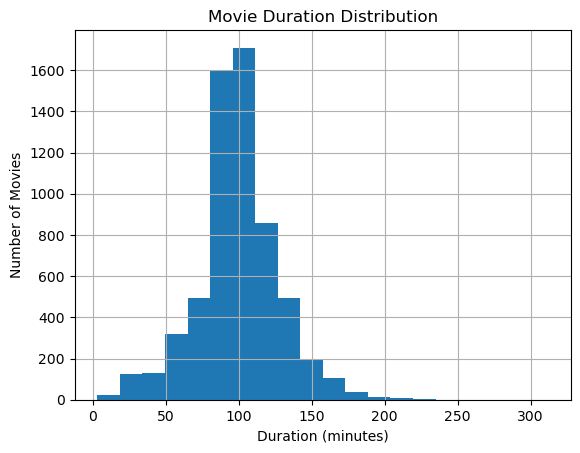

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64


In [35]:
movies = df[df["type"] == "Movie"].copy()
movies["duration_min"] = movies["duration"].str.replace(" min", "").astype(float)

movies["duration_min"].hist(bins=20)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.show()

print(movies["duration_min"].describe())

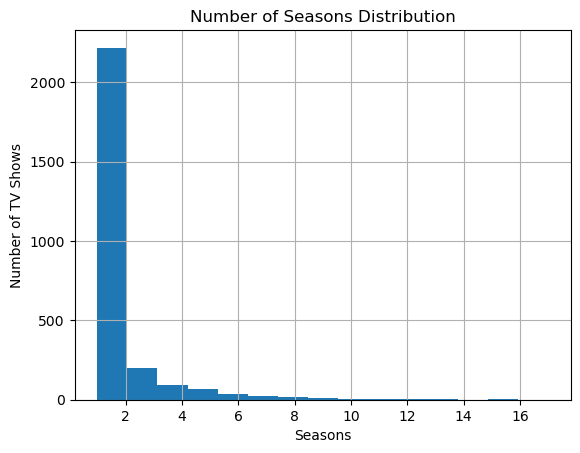

In [37]:
tv_shows = df[df["type"] == "TV Show"].copy()
tv_shows["seasons"] = tv_shows["duration"].str.replace(" Season", "").str.replace("s", "").astype(float)

tv_shows["seasons"].hist(bins=15)
plt.title("Number of Seasons Distribution")
plt.xlabel("Seasons")
plt.ylabel("Number of TV Shows")
plt.show()

In [ ]:
***Most netflix shows have only one season which is very common.
    The number of shows drops quickly as season count goes up.

country         type   
India           Movie       893
                TV Show      79
Japan           Movie        76
                TV Show     169
South Korea     Movie        41
                TV Show     158
United Kingdom  Movie       206
                TV Show     213
United States   Movie      2058
                TV Show     760
dtype: int64


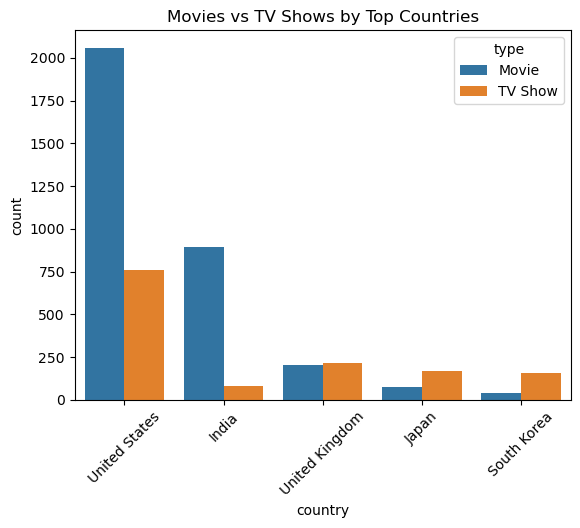

In [40]:
top_countries = df["country"].value_counts().head(5).index

subset = df[df["country"].isin(top_countries)]
print(subset.groupby(["country","type"]).size())

sns.countplot(x="country", hue="type", data=subset)
plt.title("Movies vs TV Shows by Top Countries")
plt.xticks(rotation=45)
plt.show()

In [43]:
oldest = df.sort_values("release_year", ascending=True).head(5)
newest = df.sort_values("release_year", ascending=False).head(5)

print("Oldest titles:")
print(oldest[["title", "type", "release_year"]])

print("\nNewest titles:")
print(newest[["title", "type", "release_year"]])

Oldest titles:
                                              title     type  release_year
4250              Pioneers: First Women Filmmakers*  TV Show          1925
7790                                 Prelude to War    Movie          1942
8205                           The Battle of Midway    Movie          1942
8660  Undercover: How to Operate Behind Enemy Lines    Movie          1943
8739             Why We Fight: The Battle of Russia    Movie          1943

Newest titles:
                                     title     type  release_year
693                 Ali & Ratu Ratu Queens    Movie          2021
781  Black Holes | The Edge of All We Know    Movie          2021
762                           Sweet & Sour    Movie          2021
763                            Sweet Tooth  TV Show          2021
764           Trippin' with the Kandasamys    Movie          2021


month_added
July         819
December     797
September    765
April        759
October      755
August       749
March        734
January      727
June         724
November     697
May          626
February     557
Name: count, dtype: int64


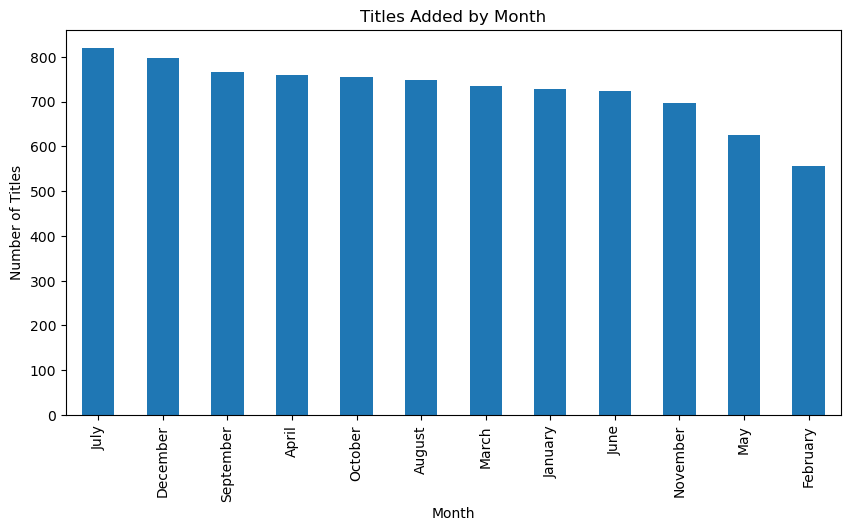

In [45]:
df["month_added"] = df["date_added"].dt.month_name()

print(df["month_added"].value_counts())

df["month_added"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Titles Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.show()

In [ ]:
**Answer:** Content on Netflix's platform grew slowly at first, then 
increased sharply in the years following its shift toward original 
programming (roughly 2015 onward), with both release years and additions 
to the catalog peaking a few years before tapering off toward the most 
recent year in the dataset (likely due to incomplete data collection for 
that year). The platform also shows seasonal patterns in when content is 
added, suggesting deliberate release timing tied to viewer engagement 
patterns throughout the year.

In [ ]:
**Answer:** Bar charts (Q63, Q64, Q67, Q68, Q69, Q70) were most effective 
for comparing categorical counts like content type, top countries, 
directors, actors, genres, and ratings. Line and bar charts over time 
(Q65, Q66, Q75) best captured how content release and additions trended 
across years and months. Histograms (Q71, Q72) worked well for showing 
the spread of movie durations and TV show season counts.

In [ ]:
**Answer:** Netflix's catalog is Movie-dominant and heavily weighted 
toward mature (TV-MA) content, with the United States as the largest 
content-producing country. Content additions grew rapidly during the 
platform's original-content expansion phase, then leveled off, suggesting 
a shift from aggressive library growth toward more selective, curated 
additions. TV Shows are mostly short-run (1-2 seasons), indicating a 
strategy favoring limited series over long-running network-style shows. 
These patterns suggest Netflix could grow its catalog further by investing 
in underrepresented genres, countries, or content ratings (e.g. more 
family-friendly content) to diversify its audience appeal.

In [ ]:
**Answer:** Netflix could invest more in family-friendly (TV-Y, TV-G) and 
younger-audience content, since the catalog is currently skewed toward 
mature ratings, to broaden its subscriber appeal. Expanding content from 
underrepresented countries beyond the top few producers (Q64) could help 
attract new international audiences. Given those TV Shows mostly have 
just 1 season, Netflix could also test renewing more successful shows for 
additional seasons to improve viewer retention, rather than relyingso 
heavily on constantly introducing new limited series.

In [ ]:
**Answer:** The Netflix dataset contains thousands of titles with no 
duplicate rows, though director, cast, and country fields had significant 
missing values, handled by labeling them "Unknown" rather than dropping 
the data. Movies outnumber TV Shows in the catalog, with the United States 
as the top content-producing country and TV-MA as the most common rating, 
showing a lean toward mature audiences. Content additions grew rapidly 
during Netflix's original-programming expansion (mid-2010s onward) before 
leveling off. TV Shows are overwhelmingly short-run (1-2 seasons), while 
movie durations cluster around the standard 90-120 minute range. Overall, 
Netflix's catalog strategy favors breadth (many limited series and films) 
over depth (long-running shows), with opportunities to diversify into 
family content and underrepresented countries to broaden its audience.